
# Customer Churn Prediction Using Machine Learning


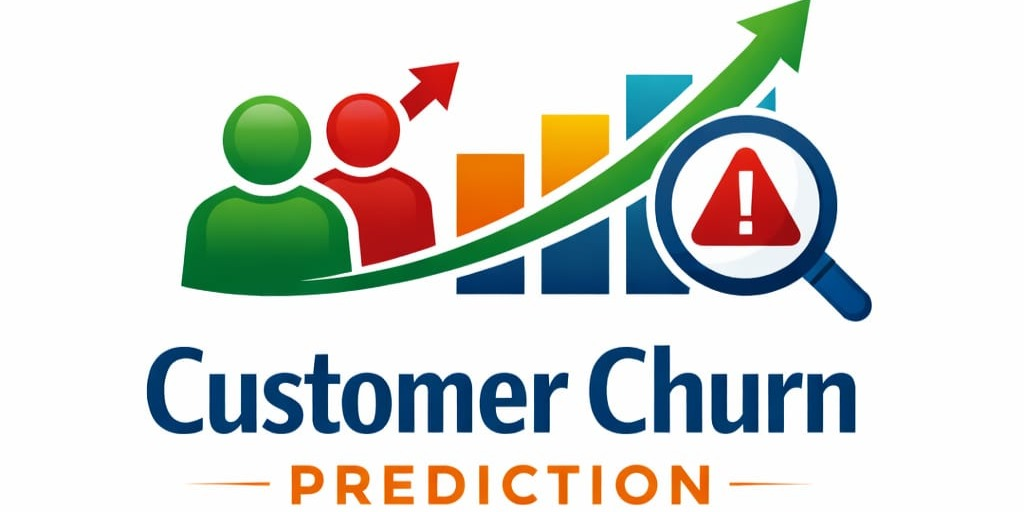

##  Import Required Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('fivethirtyeight')

##  Load Dataset

In [2]:
# Corrected path with a backslash between 'Desktop' and 'Churn.csv'
df = pd.read_csv(r'C:\Users\ADMIN\OneDrive\Desktop\Datasets\Churn.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Overview

In [3]:
df.info()  ### I Used info() to understand data types and prepare for Encoding and Cleaning.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.shape

(7043, 21)

In [5]:
df.describe() ### gives Statistical summary of numerical columns. 

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum() ## I Used isnull() to dectect missing values before data cleaning and preprocessing.

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Class Imbalance Check

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


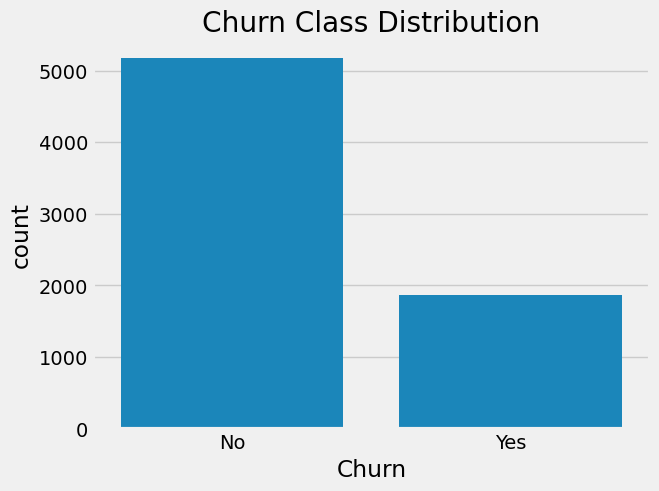

In [8]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

plt.figure()
sns.countplot(x='Churn', data=df)
plt.title('Churn Class Distribution')
plt.savefig("churn_distribution.png")
plt.show()

We check class imbalance to understand the distribution of 
the target variable (Churn). If one class dominates the other
the model may become biased towards the majority class and 
show misleading accuracy. Identifying imbalance early helps 
us choose the right evaluation metrics like ROC-AUC, 
Precision, Recall and F1-Score instead of relying only 
on accuracy.

##  Data Cleaning

We do data cleaning to handle missing values, correct data types, remove inconsistencies, and make the data suitable for analysis and machine learning models.

In [115]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

 ## Exploratory Data Analysis

EDA helps us explore, Understand, and Validate the dataset

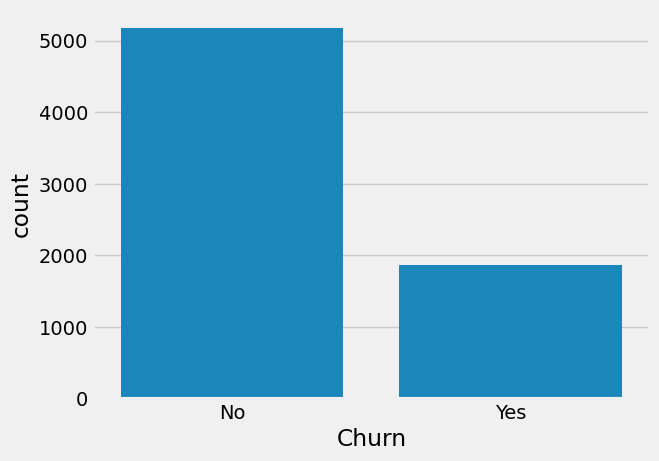

In [9]:
plt.figure(); sns.countplot(x='Churn', data=df); plt.show()

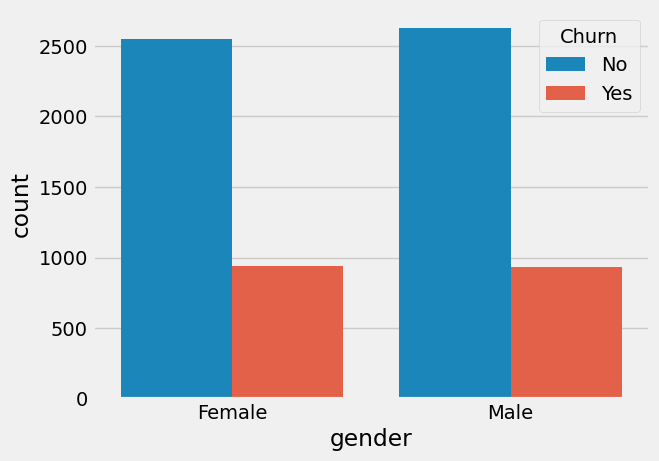

In [10]:
plt.figure(); sns.countplot(x='gender', hue='Churn', data=df); plt.show()

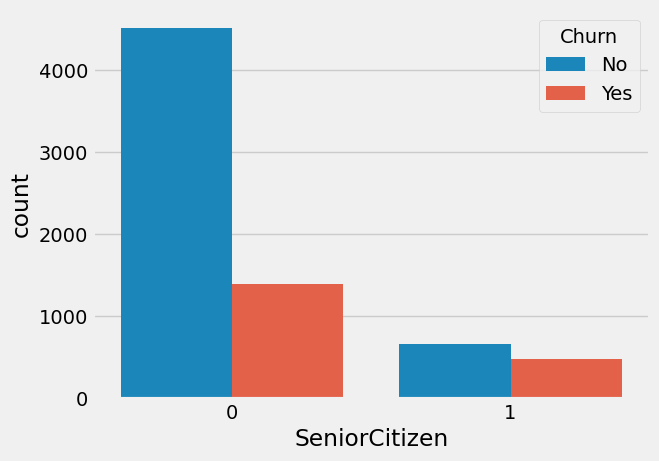

In [11]:
plt.figure(); sns.countplot(x='SeniorCitizen', hue='Churn', data=df); plt.show()

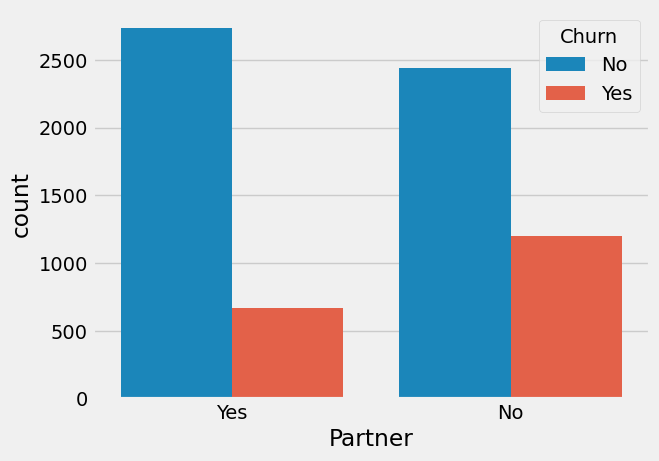

In [12]:
plt.figure(); sns.countplot(x='Partner', hue='Churn', data=df); plt.show()

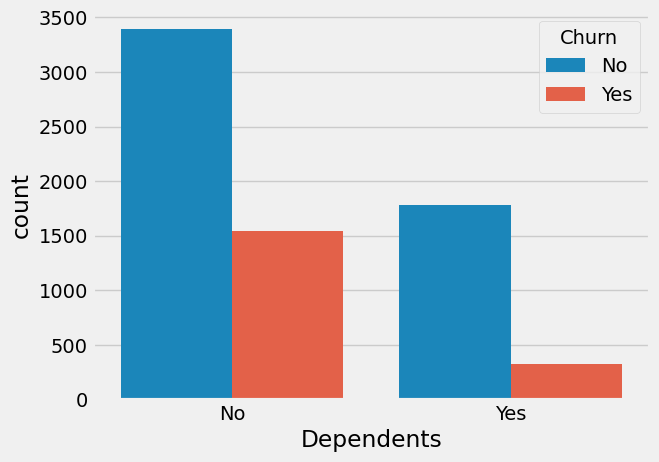

In [13]:
plt.figure(); sns.countplot(x='Dependents', hue='Churn', data=df); plt.show()

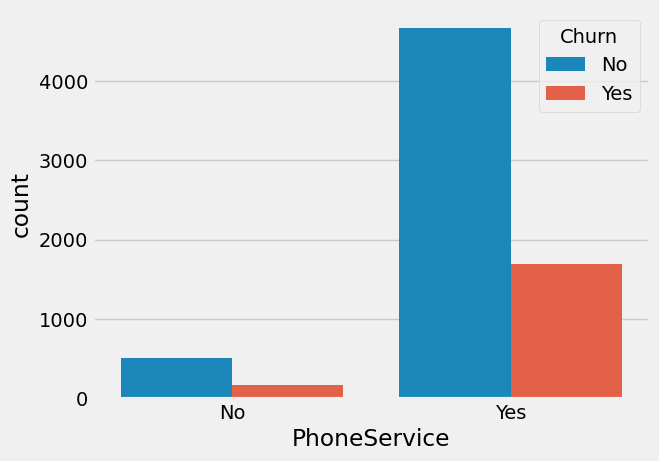

In [14]:
plt.figure(); sns.countplot(x='PhoneService', hue='Churn', data=df); plt.show()

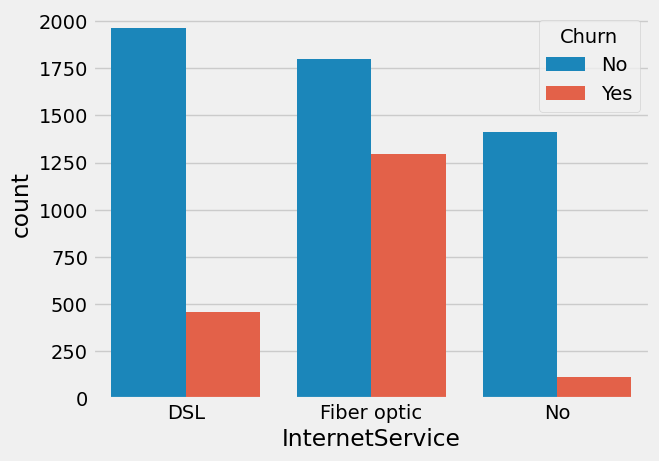

In [15]:
plt.figure(); sns.countplot(x='InternetService', hue='Churn', data=df); plt.show()

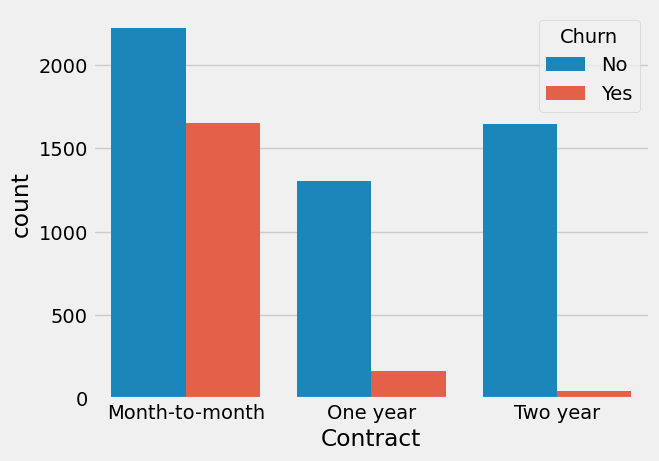

In [16]:
plt.figure(); sns.countplot(x='Contract', hue='Churn', data=df); plt.show()

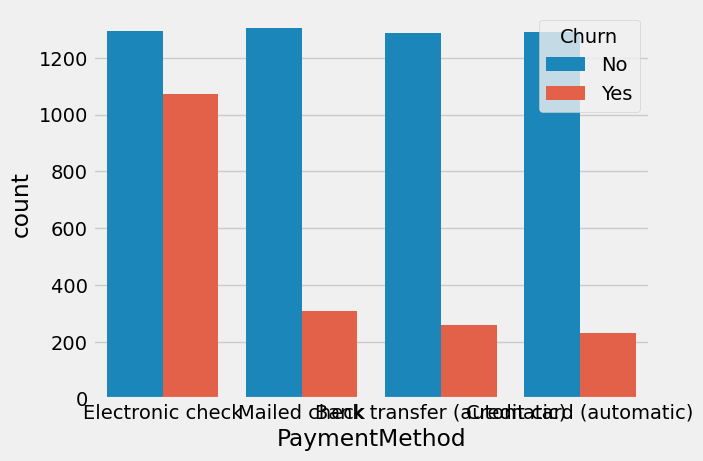

In [17]:
plt.figure(); sns.countplot(x='PaymentMethod', hue='Churn', data=df); plt.show()

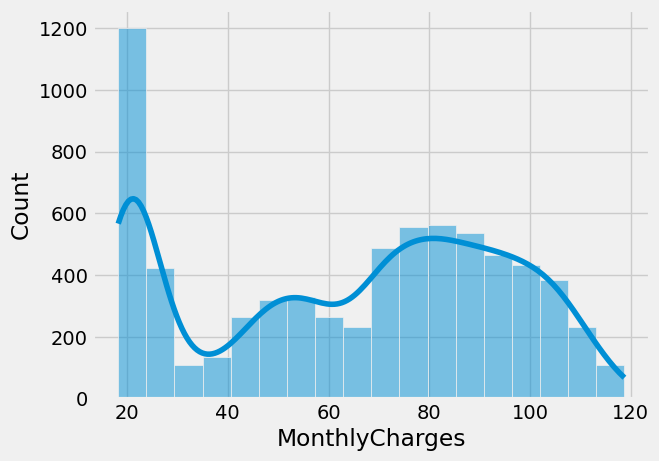

In [18]:
plt.figure(); sns.histplot(df['MonthlyCharges'], kde=True); plt.show()

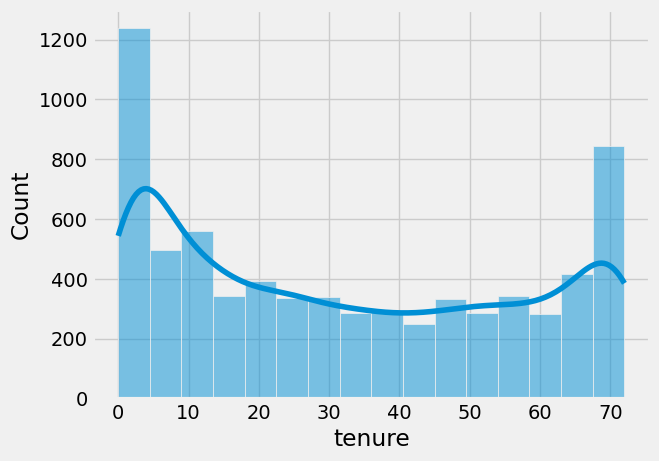

In [19]:
plt.figure(); sns.histplot(df['tenure'], kde=True); plt.show()

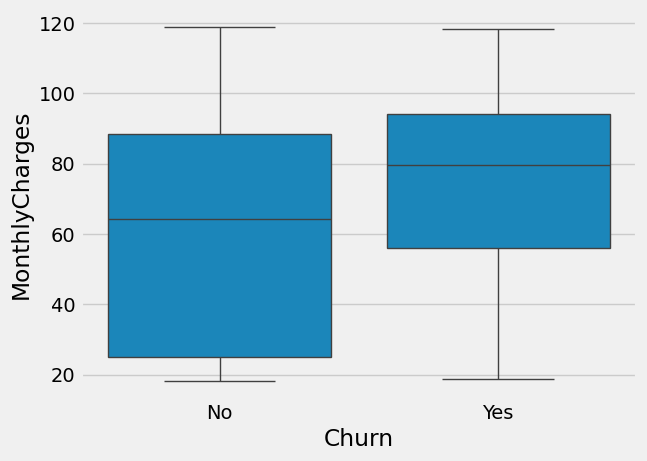

In [20]:
plt.figure(); sns.boxplot(x='Churn', y='MonthlyCharges', data=df); plt.show()

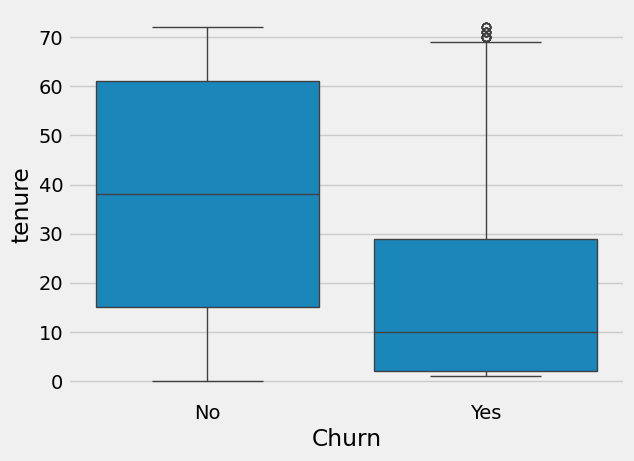

In [21]:
plt.figure(); sns.boxplot(x='Churn', y='tenure', data=df); plt.show()

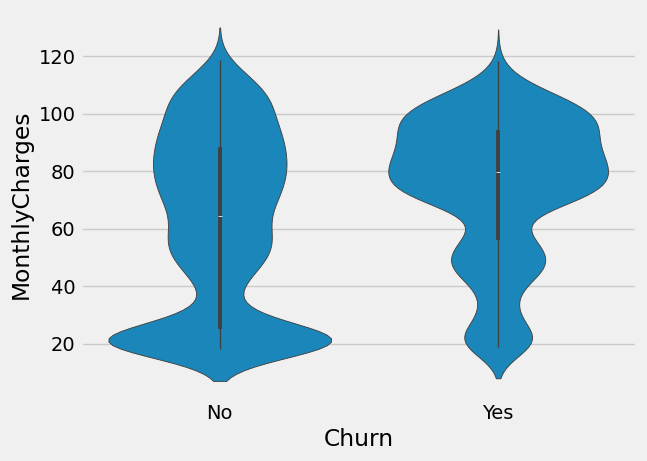

In [22]:
plt.figure(); sns.violinplot(x='Churn', y='MonthlyCharges', data=df); plt.show()

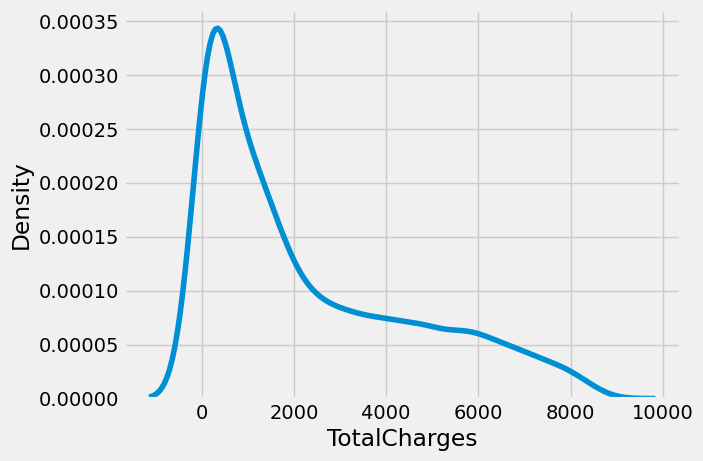

In [31]:
plt.figure(); sns.kdeplot(df['TotalCharges']); plt.show()

## Encoding & Scaling

Encoding is required to convert categorical variables into numerical format so that machine learning algorithms can process them.
Scaling ensures that all features contribute equally to the model.

In [32]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X = scaler.fit_transform(X)

## HeatMap

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

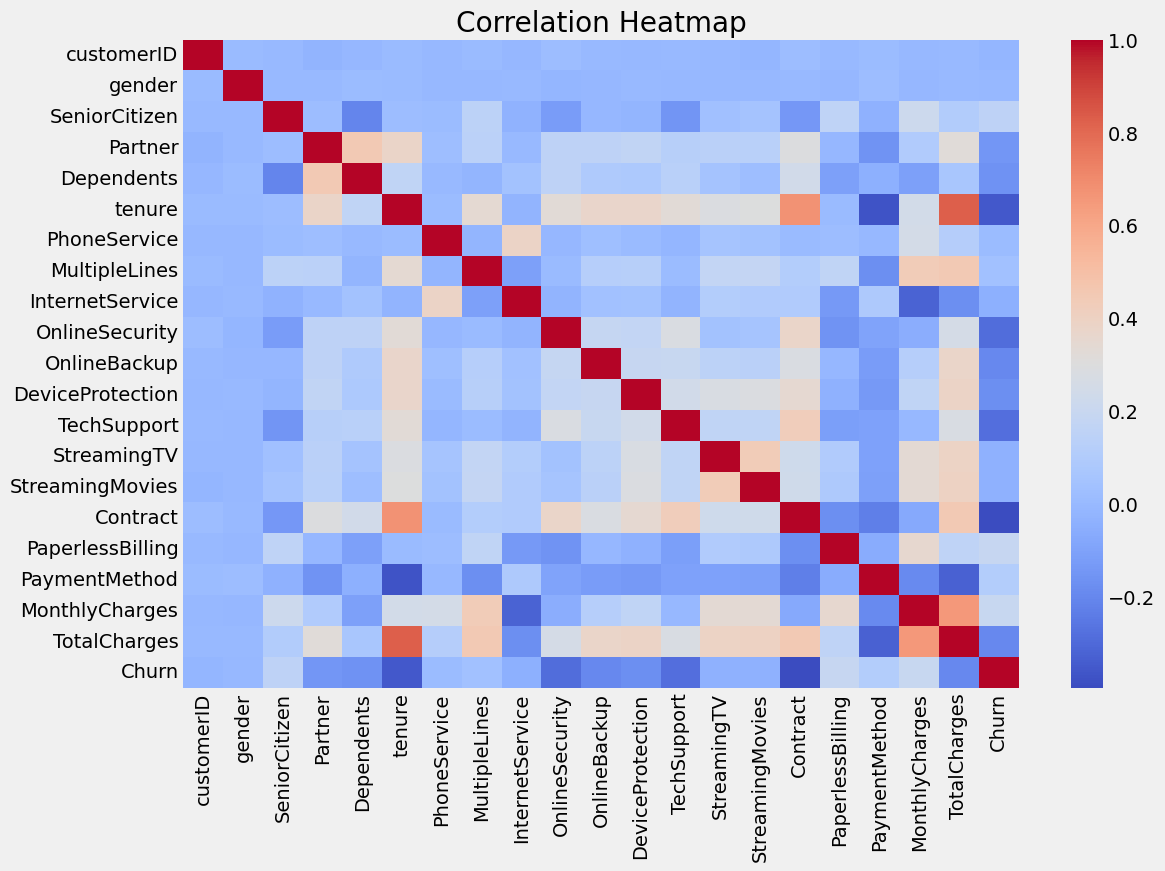

In [60]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")  # Fixed: changed "coolwarn" to "coolwarm"
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

I used a correlation heatmap during exploratory data analysis to visualize relationships between features and identify multicollinearity. 
This helped me understand which variables were strongly related and informed feature selection for the machine learning models.

## Train Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training & Evaluation

### Logistic Regression

Why we We use Logistic Regression because it is suitable for binary classification problems, 
predicts probabilities, serves as a strong baseline model, and is easy to interpret for business 
decisions.

Accuracy: 0.7867803837953091
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



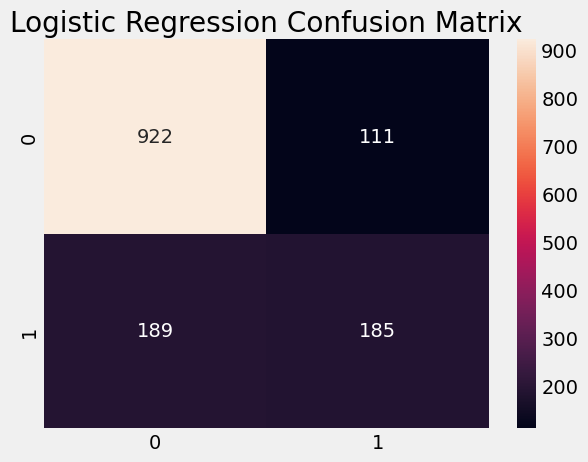

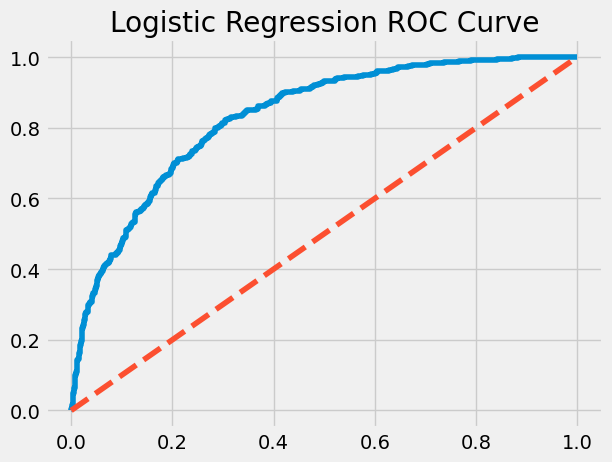

In [34]:

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('Logistic Regression ROC Curve')
plt.show()

### KNN

We use KNN because it predicts outcomes based on similarity between data points,
captures non-linear patterns, and serves as a good benchmark model for classification
problems like customer churn.

Accuracy: 0.7398720682302772
              precision    recall  f1-score   support

           0       0.82      0.83      0.82      1033
           1       0.51      0.50      0.50       374

    accuracy                           0.74      1407
   macro avg       0.67      0.66      0.66      1407
weighted avg       0.74      0.74      0.74      1407



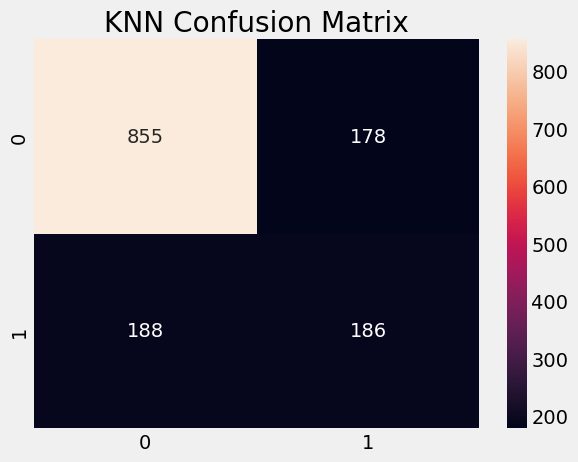

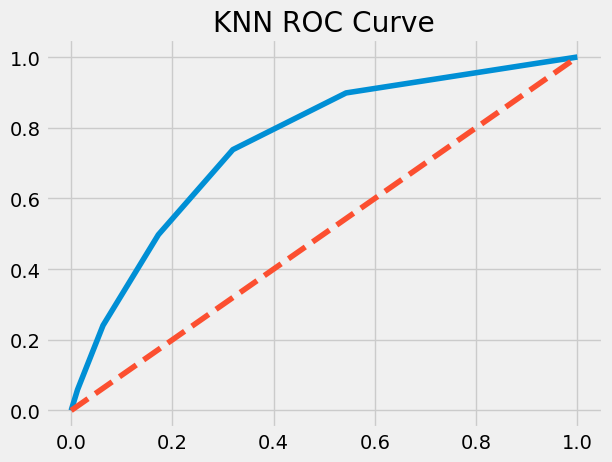

In [35]:
model = KNeighborsClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('KNN Confusion Matrix')
plt.show()

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('KNN ROC Curve')
plt.show()

### Decision Tree

We use Decision Trees because they are easy to interpret, handle non-linear relationships,
work with mixed data types, and provide clear decision rules and feature importance.

Accuracy: 0.728500355366027
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.49      0.53      0.51       374

    accuracy                           0.73      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.74      0.73      0.73      1407



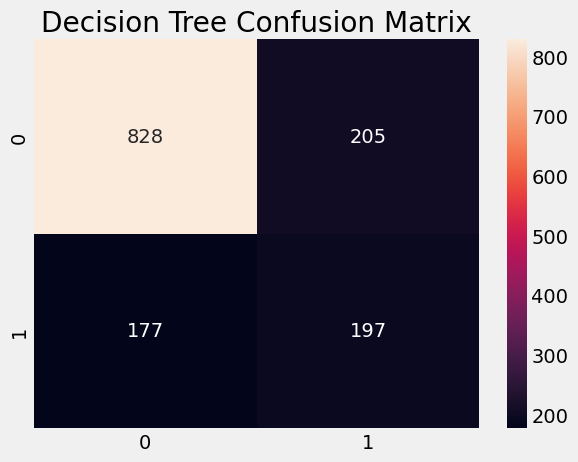

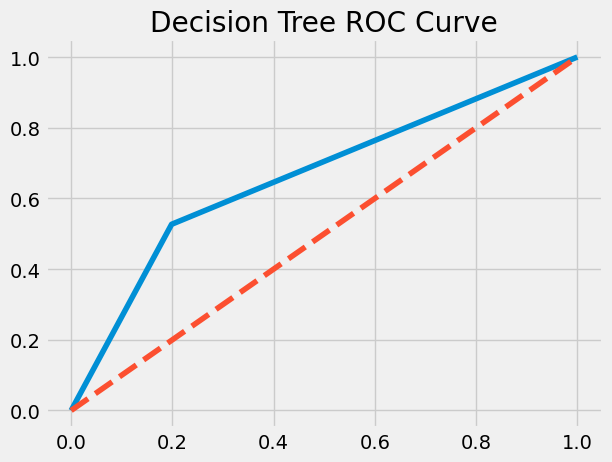

In [36]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Decision Tree Confusion Matrix')
plt.show()

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('Decision Tree ROC Curve')
plt.show()

### Random Forest

We use Random Forest because it reduces overfitting of decision trees, improves accuracy through ensemble learning, captures complex patterns, and provides feature importance.

Accuracy: 0.7860696517412935
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.45      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



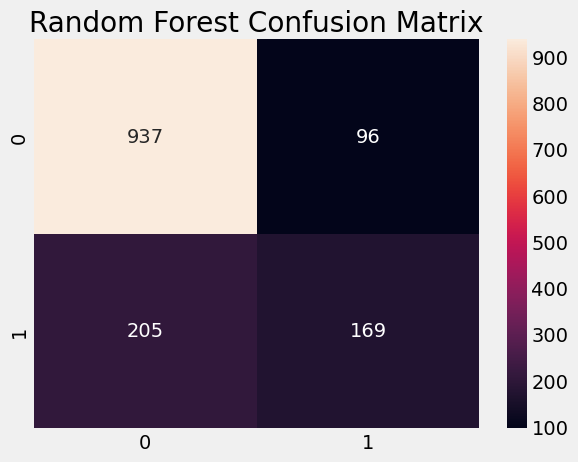

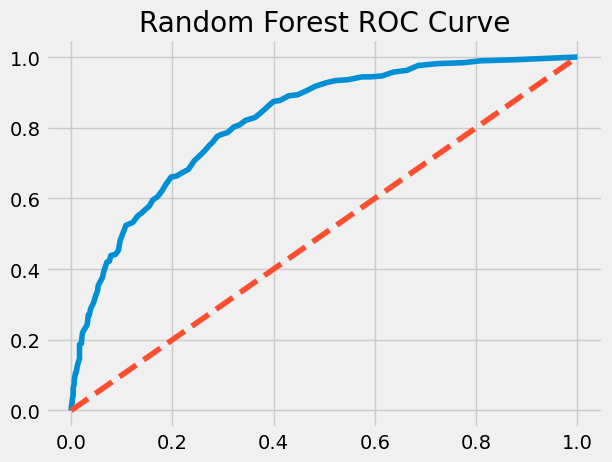

In [54]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.show()

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('Random Forest ROC Curve')
plt.savefig("Random Forest ROC Curve.png")
plt.show()
plt.show()

## Feature Importance

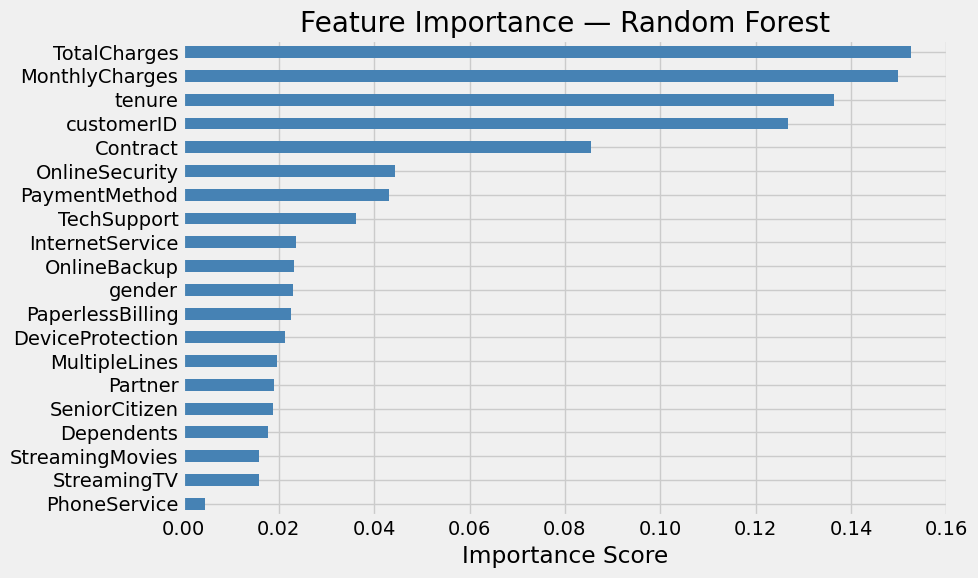

Top 5 Important Features:
TotalCharges      0.152603
MonthlyCharges    0.149936
tenure            0.136431
customerID        0.126720
Contract          0.085540
dtype: float64


In [38]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest specifically for Feature Importance
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature names
feature_names = df.drop('Churn', axis=1).columns

# Create feature importance series
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig("Feature Importance.png")
plt.show()

# Top 5 features
print("Top 5 Important Features:")
print(feat_imp.sort_values(ascending=False).head())

We use Feature Importance to identify which features 
have the most impact on predicting customer churn. 
It helps the business focus on the most influential 
factors like TotalCharges, tenure, and MonthlyCharges
to take targeted action for customer retention.

### Gradient Boosting

We use Gradient Boosting because it builds models sequentially to correct previous errors,
reduces bias, captures complex non-linear patterns, and often delivers high predictive performance.

Accuracy: 0.7903340440653873
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



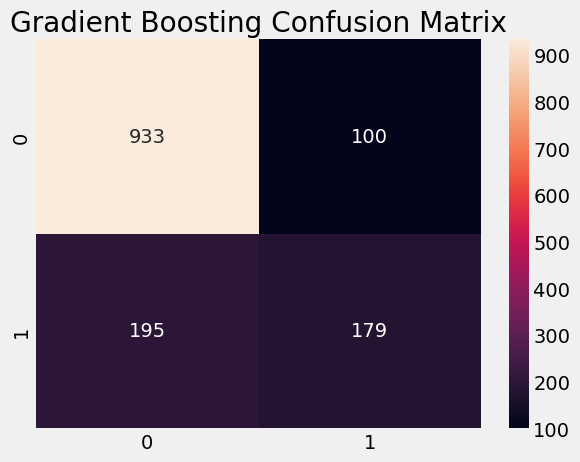

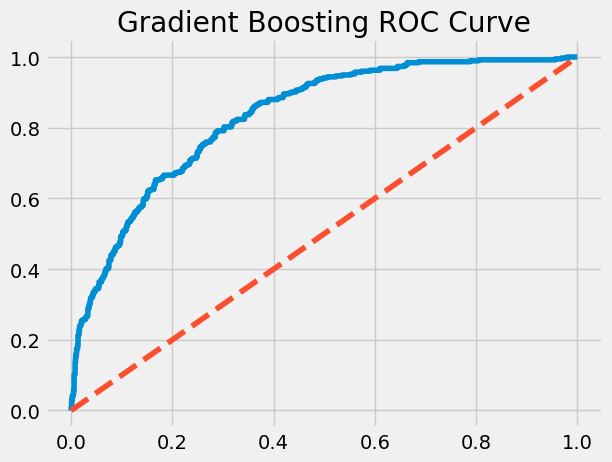

In [39]:
model = GradientBoostingClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Gradient Boosting Confusion Matrix')
plt.show()

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('Gradient Boosting ROC Curve')
plt.show()

### AdaBoost

We use AdaBoost because it adaptively focuses on misclassified data points, combines weak learners into a strong model, and improves classification performance.

Accuracy: 0.7889125799573561
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



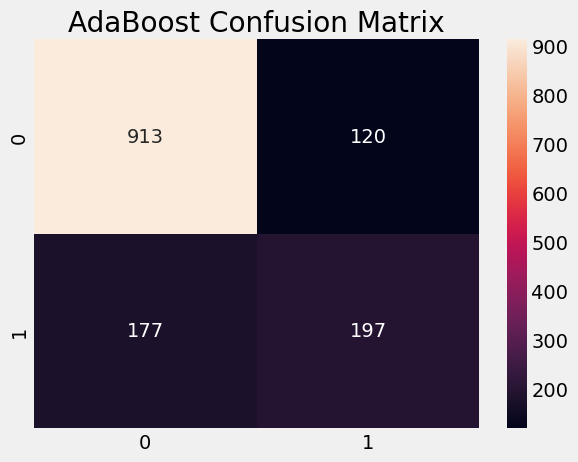

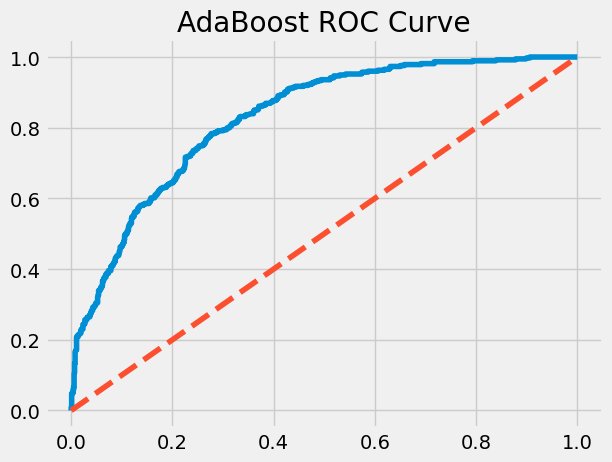

In [40]:
model = AdaBoostClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('AdaBoost Confusion Matrix')
plt.show()

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('AdaBoost ROC Curve')
plt.show()

### SVM

We use SVM because it finds an optimal decision boundary with maximum margin, 
handles high-dimensional and non-linear data using kernels, and generalizes well.

Accuracy: 0.7924662402274343
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1033
           1       0.65      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



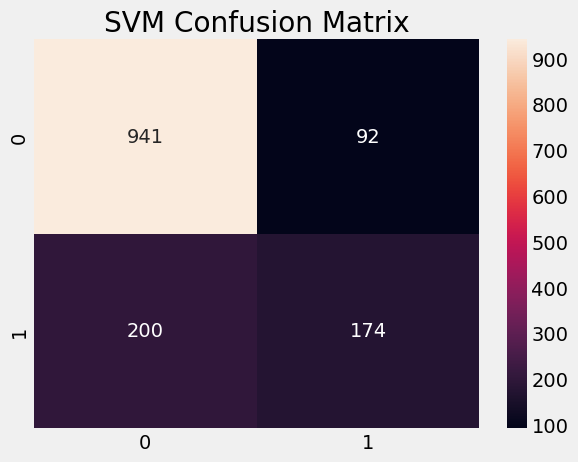

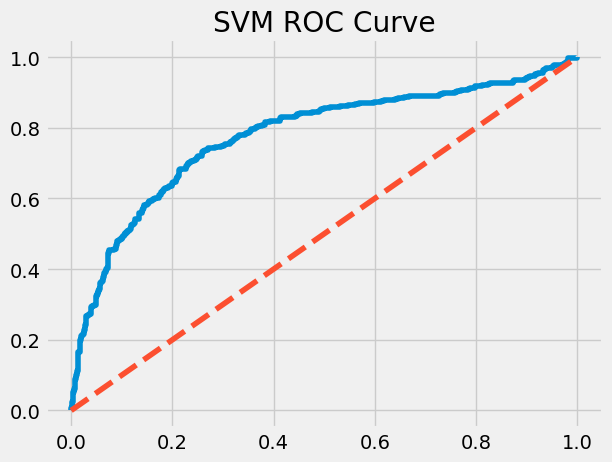

In [41]:
model = SVC(probability=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('SVM Confusion Matrix')
plt.show()

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('SVM ROC Curve')
plt.show()

### Naive Bayes

We use Naive Bayes because it is a fast, probabilistic classifier based on Bayes theorem, works well as a baseline model, and performs efficiently even with limited data.

Accuracy: 0.7398720682302772
              precision    recall  f1-score   support

           0       0.88      0.74      0.81      1033
           1       0.51      0.73      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.78      0.74      0.75      1407



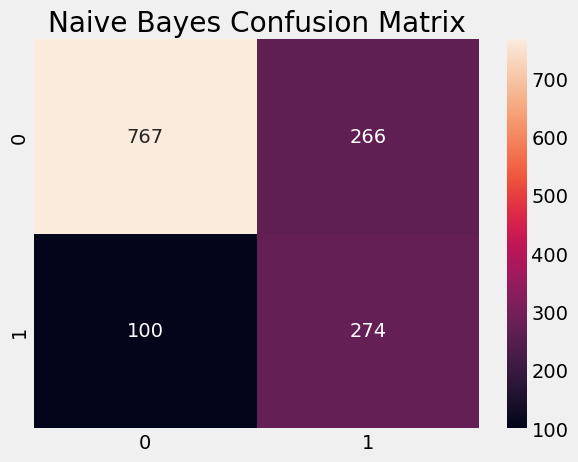

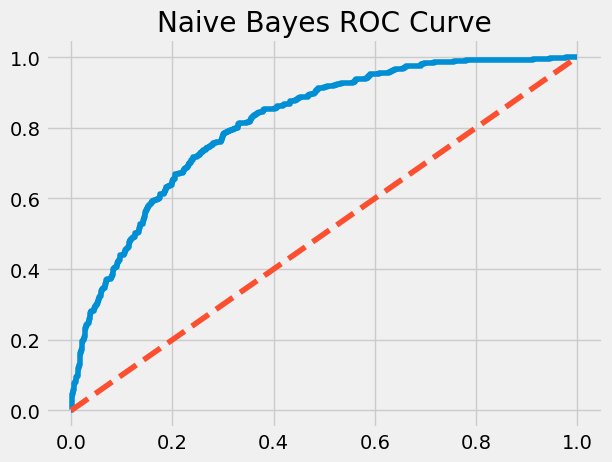

In [42]:
model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('Naive Bayes ROC Curve')
plt.show()

## ROC_AUC

We use ROC curve and AUC because they evaluate a model’s ability to distinguish between classes across all thresholds, making them more reliable than accuracy for imbalanced dataset.

In [130]:
results_df = pd.DataFrame(results.items(), columns=["Model", "ROC_AUC"])
results_df = results_df.sort_values(by="ROC_AUC", ascending=False)
results_df

,Model,ROC_AUC
1,KNN,0.620
2,SVM,0.600
4,Random Forest,0.565
5,Gradient Boosting,0.490
0,Logistic Regression,0.390
3,Naive Bayes,0.370


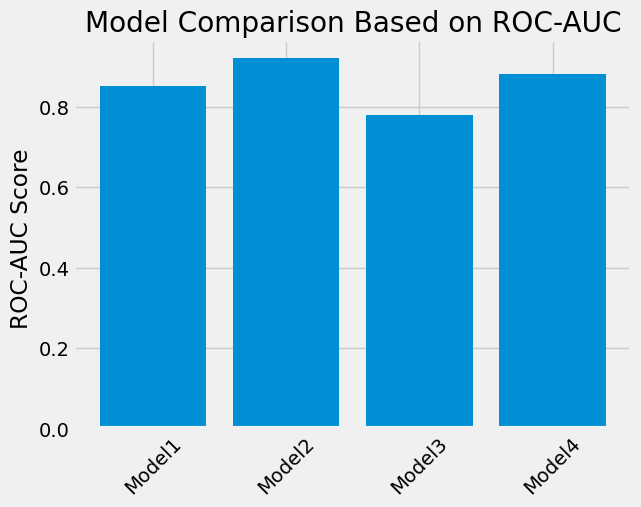

In [53]:
models = ['Model1', 'Model2', 'Model3', 'Model4']
roc_auc_scores = [0.85, 0.92, 0.78, 0.88]
results_df = pd.DataFrame({
    "Model": models,
    "ROC_AUC": roc_auc_scores
})
plt.figure()
plt.bar(results_df["Model"], results_df["ROC_AUC"])
plt.xticks(rotation=45)
plt.ylabel("ROC-AUC Score ")
plt.title("Model Comparison Based on ROC-AUC")
plt.show()

## Cross Validation

In [48]:
cv_models = {
    'Random Forest':       RandomForestClassifier(),
    'Gradient Boosting':   GradientBoostingClassifier(),
    'Logistic Regression': LogisticRegression()
}

print("5-Fold Cross Validation Results:")
print("-" * 40)

for name, m in cv_models.items():
    scores = cross_val_score(m, X, y, cv=5, scoring='accuracy')
    print(f"{name}")
    print(f"  Mean Accuracy: {scores.mean():.4f}")
    print(f"  Std Dev:       {scores.std():.4f}")
    print()

5-Fold Cross Validation Results:
----------------------------------------
Random Forest
  Mean Accuracy: 0.7935
  Std Dev:       0.0102

Gradient Boosting
  Mean Accuracy: 0.8006
  Std Dev:       0.0101

Logistic Regression
  Mean Accuracy: 0.8025
  Std Dev:       0.0092



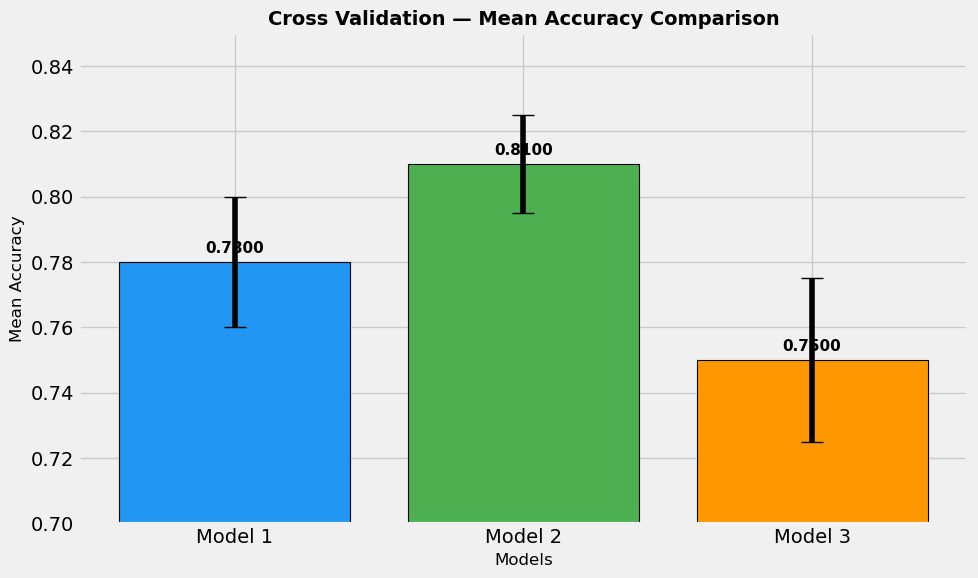

In [49]:
# Define the missing variables first
cv_names = ['Model 1', 'Model 2', 'Model 3']  # Replace with your actual model names
cv_means = [0.78, 0.81, 0.75]  # Replace with your actual mean accuracy values
cv_stds = [0.02, 0.015, 0.025]  # Replace with your actual standard deviation values

# Now create the plot
plt.figure(figsize=(10, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800']

bars = plt.bar(
    cv_names,
    cv_means,
    yerr=cv_stds,
    color=colors,
    capsize=8,
    edgecolor='black',
    linewidth=0.8
)

for bar, mean in zip(bars, cv_means):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{mean:.4f}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )

plt.title('Cross Validation — Mean Accuracy Comparison',
          fontsize=14, fontweight='bold')
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.ylim(0.70, 0.85)
plt.tight_layout()
plt.show()

We use Cross Validation to check if our model performs 
consistently on different parts of the data. It gives 
a more reliable accuracy score than a single train-test split 
and helps us detect if the model is overfitting.

## Hyperparameter Tuning

In [50]:
param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [3, 5, 7],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:  ", round(grid_search.best_score_, 4))

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print("Test Accuracy:  ", round(accuracy_score(y_test, y_pred_best), 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'max_depth': 7, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score:   0.8055
Test Accuracy:   0.7953


We use Hyperparameter Tuning to find the best settings 
for our model to improve its performance. GridSearchCV 
automatically tests all parameter combinations and 
returns the combination that gives the highest accuracy.

## Model Accuracy

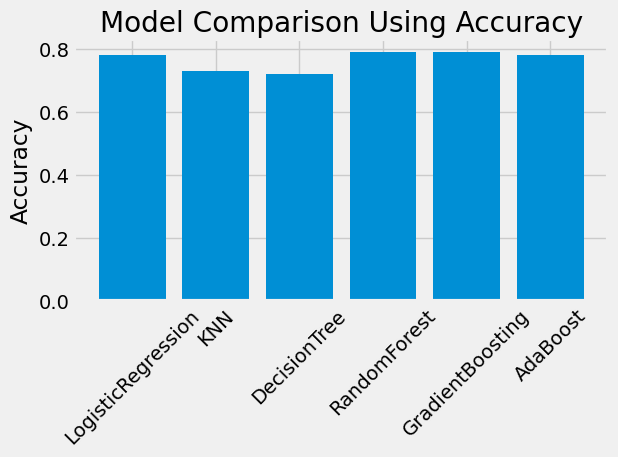

In [51]:
%matplotlib inline
accuracy_df = pd.DataFrame({
    "Model": ["LogisticRegression", "KNN", "DecisionTree", "RandomForest", "GradientBoosting", 
              "AdaBoost"],  # Changed key from "index" to "Model"
    "Accuracy": [0.78, 0.73, 0.72, 0.79, 0.79, 0.78]
})

plt.figure()
plt.bar(accuracy_df["Model"], accuracy_df["Accuracy"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison Using Accuracy")
plt.tight_layout()
plt.show()

## Best Model Selection

In [45]:
final_results = pd.DataFrame({
    'Model': ['LogisticRegression', 'KNN', 'DecisionTree',
              'RandomForest', 'GradientBoosting', 'AdaBoost'],
    'Accuracy': [0.78, 0.73, 0.72, 0.79, 0.79, 0.78]
})

print("=" * 45)
print("      FINAL MODEL COMPARISON")
print("=" * 45)
print(final_results.to_string(index=False))
print("=" * 45)

best = final_results.loc[final_results['Accuracy'].idxmax()]
print(f"\nBest Model: {best['Model']}")
print(f"Accuracy:   {best['Accuracy']}")

      FINAL MODEL COMPARISON
             Model  Accuracy
LogisticRegression      0.78
               KNN      0.73
      DecisionTree      0.72
      RandomForest      0.79
  GradientBoosting      0.79
          AdaBoost      0.78

Best Model: RandomForest
Accuracy:   0.79


## Summary

This project focused on predicting customer churn using machine learning techniques on a real-world
telecom dataset. After performing data cleaning, exploratory data analysis, and model training, 
multiple models were evaluated and compared. Among all models, Gradient Boosting delivered the 
best predictive performance. The final model can help businesses identify high-risk customers and 
takeproactive steps to improve customer retention.